# Trabajo Fin de Máster  
### Análisis de la Ciudad mediante Aprendizaje Supervisado  
#### Detección Automática de Tipologías Residenciales y Patrones de Cerramiento: Interpretabilidad vs Rendimiento

**Master Universitario en Ciencia de Datos e Ingeniería de Computadores (Universidad de Granada)**

> **Autor:** David Fernández Martínez    
> **Email personal:** david.fernxndez.martinez@gmail.com  
> **Email académico:** davidfm8@correo.ugr.es  
> **LinkedIn:** [linkedin.com/in/david-fernández-martínez](https://www.linkedin.com/in/david-fern%C3%A1ndez-mart%C3%ADnez/)  
> **GitHub:** [github.com/davidfernxndez](https://github.com/davidfernxndez)

---

## Análisis del rendimiento: Modelos interpretables vs caja negra

### 📝 Descripción del notebook
En este *notebook* se analizan los resultados obtenidos en el experimento de rendimiento realizado en el *notebook 03_Performance_experiment.ipynb*. Para ello se realiza una comparación del rendimiento global de todos los modelos y se profundiza en el rendimiento desagregado por clase. El análisis se enmarca en el *trade-off* entre interpretabilidad y rendimiento por lo que las conclusiones obtenidas se centran en las mejoras que aportan los modelos "caja negra" frente a los interpretables en términos de rendimiento.

### Indice de contenidos
1. [Análisis del rendimiento global](#global)

2. [Análisis desagregado del rendimiento por clase](#por_clase)
    * [2.1. Análisis comparativo entre XGBoost y árbol de decisión](#arbol)
    * [2.2 Análisis comparativo entre XGBoost y Regresión Logística Multinomial](#regresion)

# Configuración de entorno e *imports*

Este proyecto ha sido realizado en un entorno Anaconda con la versión 3.11.15 de *Python*. Las versiones de las librerias requeridas se encuentran en el fichero *requirements.txt*.

En esta sección se importan las librerias necesarias para la ejecución de este fichero jupyter notebook, se activa el *reload* de módulos externos y se configuran aspectos globales y de reproducibilidad.

In [1]:
# jupyter extensions to automatically reload external modules
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration object
from src.config import cfg

# Performance analysis methods
from src.performance_utils import analyze_global_performance, plot_confusion_matrix, compare_class_metrics

**Import troubleshooting**

If the `src` imports fail when running this notebook in a different environment,
uncomment and execute the following cell:

```python
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
```

In [3]:
# Global configuration
sns.set_theme(style="ticks", context="notebook")
plt.rcParams["font.family"] = "sans-serif"
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

In [4]:
# Set performance results folder
results_folder = Path(cfg.OUTPUT_DIR) / f"{cfg.OUTER_SPLITS}x{cfg.INNER_SPLITS}_NCV"

In [5]:
# Reproducibility
SEED = cfg.SEED 
np.random.seed(SEED)
random.seed(SEED)

<a id="global"></a>
# 1. Análisis del rendimiento global

En esta sección se realiza un análisis comparativa del rendimiento global de los distintos modelos de clasificación mediante las métricas F1-Score Macro y el Matthews Correlation Coefficient (MCC). 

Para realizar este análisis, se ha desarrollado la función *analyze_global_performance()* en el módulo *src/performance_utils.py.* Esta función genera los siguientes elementos:
* **Tabla resumen de rendimiento global**. Muestra para cada modelo el valor medio y la desviación estándar $(\mu \pm \sigma)$ de las métricas F1-Score Macro, MCC y Accuracy obtenidas a lo largo de los diferentes *folds* de validación cruzada externa.
* **Gráfico de barras comparativo**. Representa los valores promedio de F1-Score Macro y MCC para cada modelo, ofreciendo una comparación visual del rendimiento medio en ambas métricas.
* **Diagramas de cajas (Box Plots)**. Muestra la distribución de los valores de F1-Score Macro y MCC obtenidos en los distintos *folds*. Esta visualización aporta información sobre la estabilidad de los modelos ante distintas particiones del conjunto de datos.
* **Mapa de calor (Heatmap) de diferencias absolutas**. Cuantifica las diferencia absoluta entre los valores promedio de F1-Score Macro de todos los pares de modelos, cuantificando la mejora absoluta de un modelo frente a otro.

model_name,F1-Score macro,MCC,Accuracy
Decision Tree,0.834 ± 0.032,0.844 ± 0.039,0.889 ± 0.028
Logistic Regression,0.890 ± 0.009,0.890 ± 0.013,0.922 ± 0.010
Random Forest,0.908 ± 0.038,0.920 ± 0.027,0.944 ± 0.019
SVM,0.909 ± 0.029,0.923 ± 0.021,0.945 ± 0.015
XGBoost,0.932 ± 0.009,0.941 ± 0.006,0.958 ± 0.004


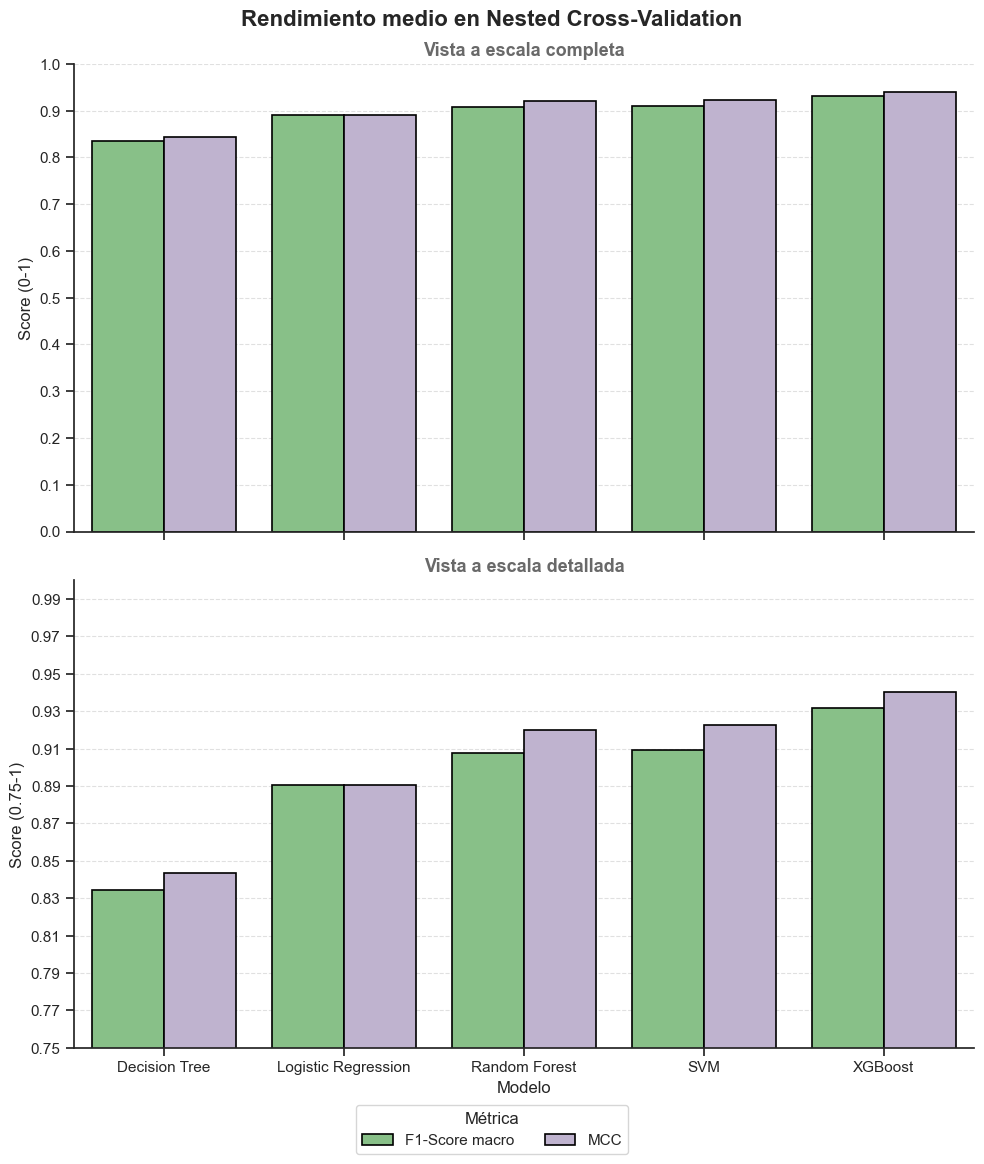

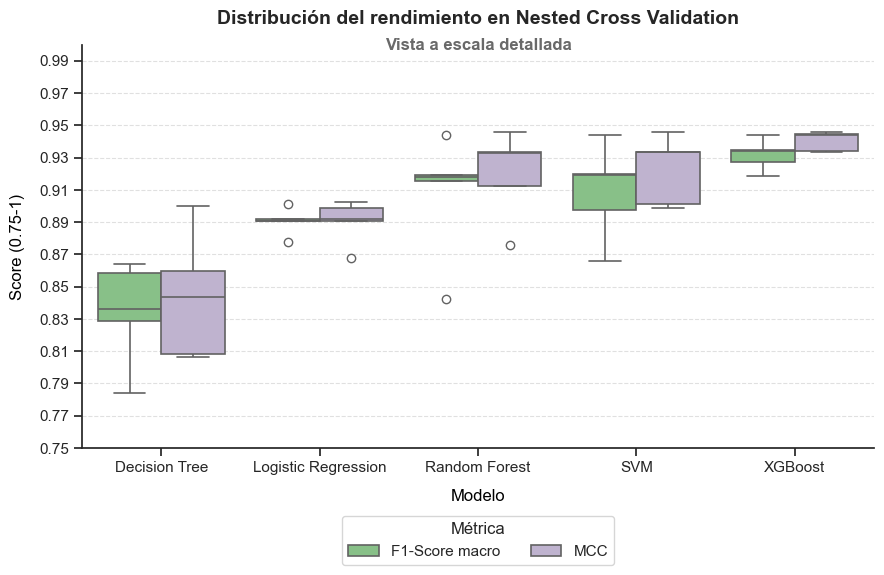

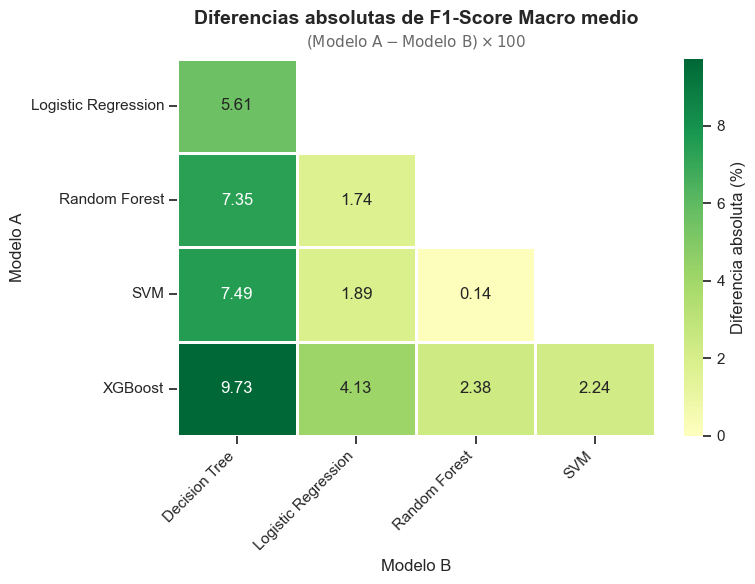

In [31]:
# Concatenate global metrics in all models
models_name = ["Logistic_Regression", "Decision_Tree", "SVM", "Random_Forest", "XGBoost"]
global_metrics_df = pd.concat(
    [
        pd.read_csv(
            results_folder / model / f"{model}_global_metrics.csv"
        )
        for model in models_name
    ],
    ignore_index=True
)
_ = analyze_global_performance(global_metrics_df, y_lim=[0.75,1])

Los resultados obtenidos muestran una tendencia en la que el rendimiento aumenta a medida que crece la complejidad de los modelos evaluados, evidenciando el compromiso existente entre capacidad predictiva e interpretabilidad. El árbol de decisión establece el rendimiento base del experimento, alcanzando un F1-Score Macro medio del $83.43\%$ y un MCC medio del $84.37\%$. Por el contrario, XGBoost representa el máximo rendimiento observado, con un F1-Score Macro medio del $93.17\%$ y un MCC medio del $94.05\%$. 

Las métricas F1-Score Macro y Matthews Correlation Coefficient (MCC) muestran un comportamiento consistente entre los modelos evaluados, manteniendo el mismo ranking de rendimiento. Esta cohesión refuerza la robustez del análisis, ya que el ranking permanece invariable bajo criterios de evaluación complementarios.

El Heat Map de diferencias absolutas revela que los modelos "caja negra" presentan mejoras de rendimiento considerables frente a los modelos interpretables. En términos de F1-Score Macro medio, las diferencias absolutas respecto al árbol de decisión oscilan entre $5$ y $10$ puntos porcentuales, mientras que las mejoras respecto a la regresión logística multinomial se sitúan entre $2$ y $4$ puntos porcentuales. Estos resultados muestran que los modelos interpretables pueden capturar parte de la estructura subyacente del problema ofreciendo un rendimiento aceptable. Sin embargo, para alcanzar rendimientos elevados se requiere de modelos de mayor complejidad.

Los modelos "caja negra" presentan un rendimiento muy similar entre sí, en términos de F1-Score Macro medio, XGBoost obtiene una ventaja moderada respecto a Random Forest ($+2.38$ puntos porcentuales) y SVM ($+2.24$ puntos porcentuales). En el diagrama de cajas (Box Plot) de la distribución del rendimiento, se observan diferencias en cuanto a la estabilidad de los modelos. XGBoost presenta una variabilidad significativamente menor, caracterizada por cajas estrechas y ausencia de *outiers* lo que indica que las métricas se concentran en valores muy similares para todas las particiones de la validación cruzada. Por el contrario,  tanto como SVM presentan una dispersión notablemente más acusada. Puede concluirse que XGBoost es el modelo con mayor rendimiento y estabilidad ante distintas particiones en el conjunto de datos, por lo que será el modelo "caja negra" referencia en este experimento.

La diferencia de rendimiento entre los modelos interpretables es más acusada que la observada entre los modelos "caja negra". La regresión logística multinomial supera al árbol de decisión en $5.61$ puntos porcentuales en términos de F1-Score Macro medio. Respecto a XGBoost, el árbol de decisión se sitúa a una distancia de $9.73$ puntos porcentuales mientras que la regresión logística multinomial reduce está diferencia a aproximadamente la mitad ($4.13$ puntos porcentuales). 

La regresión logística multinomial se sitúa como el modelo más equilibrado del experimento, obteniendo un rendimiento global cercano a los modelos "caja negra" y manteniendo un alto grado de explicabilidad intrínseca. Aunque la interpretabilidad de este modelo no es tan directa como las reglas lógicas de un árbol de decisión, la interpretación de sus coeficientes permite cuantificar de forma transparente la influencia que tiene cada variable en la clasificación, lo que supone un alto grado de explicabilidad frente a SVM, Random Forest o XGBoost.

<a id="por_clase"></a>
# 2. Análisis desagregado del rendimiento por clase

Para analizar con mayor detalle las mejoras de rendimiento asociadas al uso de modelos "caja negra", se realiza un estudio del rendimiento a nivel de clase de la variable objetivo. Este análisis permite identificar qué categorías se benefician en mayor medida del uso de modelos más complejos, así como determinar si dichas mejoras se producen principalmente en términos de precisión o de recall.

Se selecciona XGBoost como modelo "caja negra" de referencia, puesto que presenta el mejor rendimiento y estabilidad global. Las mejoras de este modelo se comparan tanto con el árbol de decisión como con la regresión logística multinomial. Estos algoritmos presentan mecanismos de interpretabilidad diferentes, que puede influir en la elección del modelo en función de la familiaridad del usuario con estos mecanismos. Por lo tanto, se evalua la mejora que proporciona XGBoost frente a ambos modelos.

Para realizar este análisis se han desarrollado dos funciones en el módulo *src/performance_utils.py*: *plot_confusion_matrix()* y *compare_class_metrics()*. La primera genera la matriz de confusión *out-of-fold* normalizada, permitiendo examinar la tasa de acierto de cada categoría, así como los errores de clasificación que se producen entre clases.

La función *compare_class_metrics()* genera dos visualizaciones complementarias:

* **Gráfico de barras comparativo.** Representa el F1-Score obtenido en cada clase por los modelos comparados. Esta visualización permite identificar qué categorías experimentan las mayores diferencias de rendimiento y por tanto se benefician más por el uso de un modelo de mayor complejidad.
* **Mapa de calor (Heatmap) de diferencias relativas**. Representa la diferencia relativa porcentual en precisión y recall entre el modelo "caja negra" y el modelo interpretable utilizado como referencia. Esta visualización permite descomponer las mejoras observadas en el F1-Score e identificar si estas se deben principalmente a una mayor precisión, a una mayor capacidad de detección (recall) o a una combinación de ambas.

En conjunto, estas herramientas proporcionan una visión detallada del comportamiento de los modelos a nivel de clase y sirven de apoyo para diagnosticar con mayor profundidad las ventajas y limitaciones de XGBoost frente a los modelos interpretables.

<a id="arbol"></a>
## 2.1 Análisis comparativo entre XGBoost y árbol de decisión

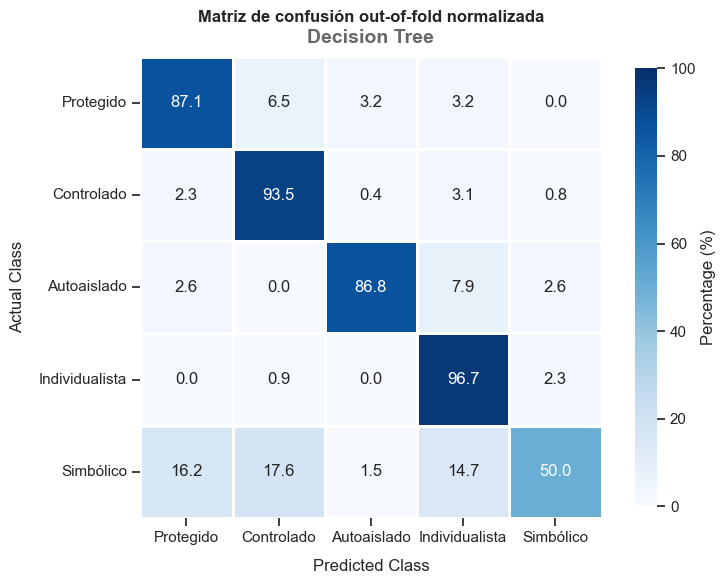

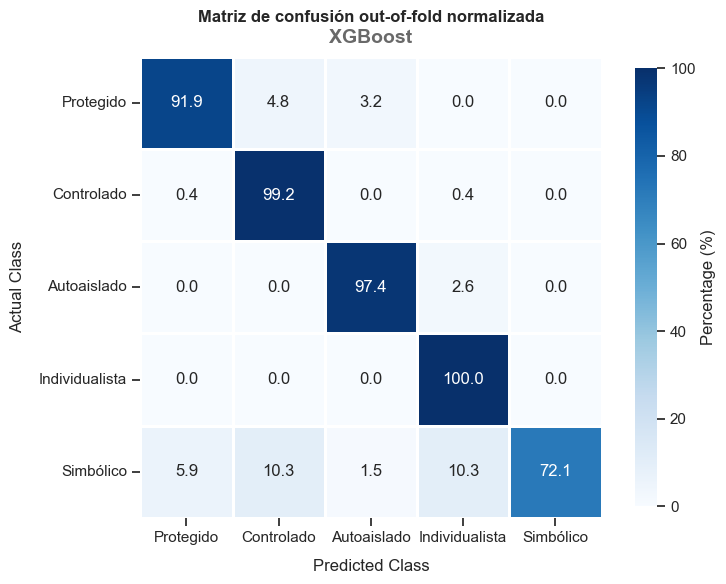

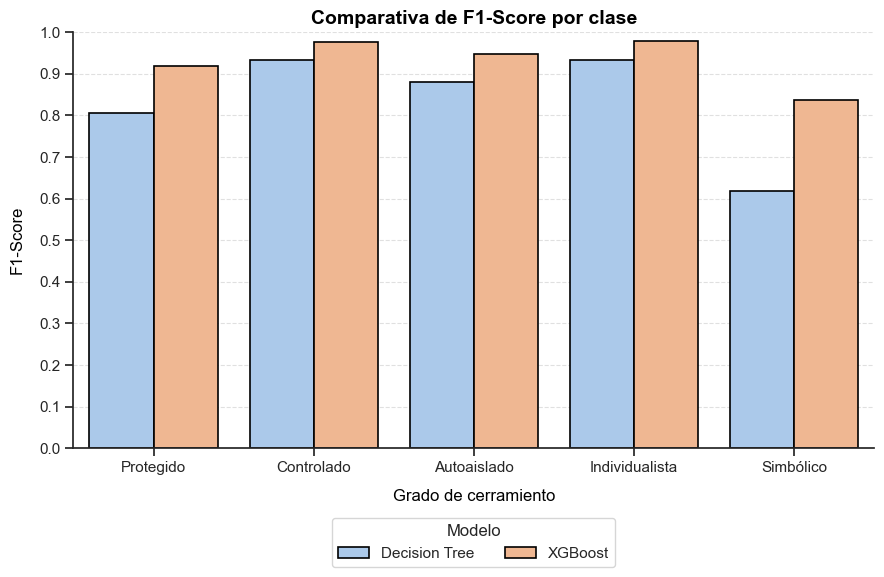

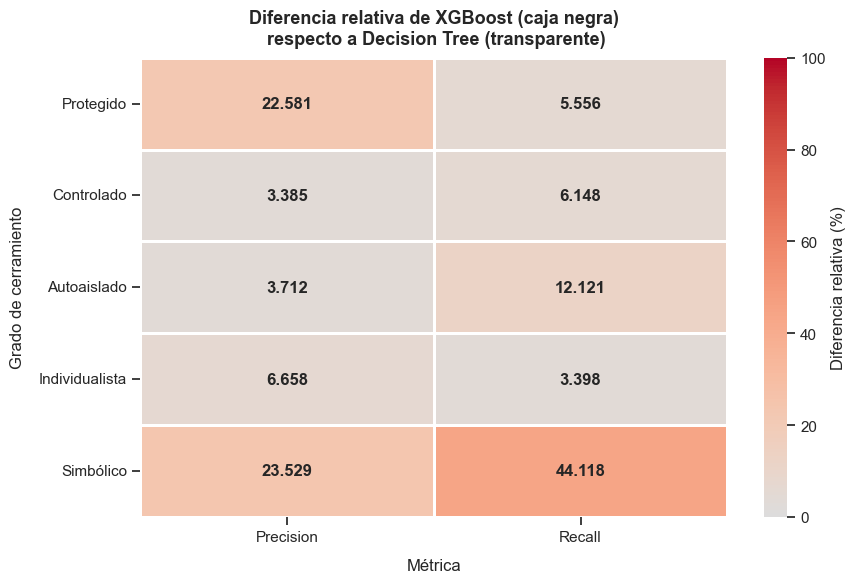

In [46]:
models_name = ["Decision_Tree", "XGBoost"]
list_metrics_df = []
for model in models_name:
    # Read confusion matrix file
    confusion_matrix_df = pd.read_csv(results_folder / model / f"{model}_confusion_matrix.csv", index_col=0)
    
    # Read class metric file
    list_metrics_df.append(pd.read_csv(results_folder/ model / f"{model}_class_metrics.csv"))

    # Plot Confusion Matrix
    _ = plot_confusion_matrix(confusion_matrix_df, label_map=cfg.TARGET_LABEL_MAP, model_name=model)

# Concatenate class metrics files and plot visualizations
class_metrics_df = pd.concat(list_metrics_df, ignore_index=True)
_ = compare_class_metrics(class_metrics_df, models_name[0], models_name[1], label_map=cfg.TARGET_LABEL_MAP)

XGBoost mejora el rendimiento en todas las categorías de la variable objetivo. Sin embargo, las diferencias más significativas se concentran en las clases menos representadas en el conjunto de datos: *Protegido*, *Autoaislado* y *Simbólico*. 

La mejora más destacada se observa en la categoría *Simbólico*. El Heat Map muestra una ganancia relativa del $23.5\%$ en precisión y del $44.1\%$ en recall, respecto al árbol de decisión. La diferencia es especialmente acusada en términos de recall, lo que indica que XGBoost es capaz de identificar una proporción considerablemente mayor de los complejos residenciales pertenecientes a esta categoría. En la matriz de confusión del arbol de decisión se observa que tan solo es capaz de clasificar correctamente el $50\%$ de los complejos residenciales de este grado de cerramiento. El uso de XGBoost beneficia a esta categoría tanto en la reducción de falsas alarmas, como especialmente en el incremento de la detección de casos reales.

En la categoría *Protegido*, la mejora se concentra en la precisión, que aumenta un $22.5\%$ de forma relativa respecto al árbol de decisión. Sobre la matriz de confusión se identifica que esta mejora está estrechamente relacionada con el incremento del recall en la categoría *Simbólico*. En el árbol de decisión un $16.2\%$ de los complejos residenciales *Simbólicos* han sido clasificados erróneamente como *Protegidos*, mientas que en XGBoost esta confusión se reduce al $5.9\%$. 

La mejora en el recall de la categoría *Protegido* es más moderada. Esto sugiere que el árbol de decisión es capaz de identificar correctamente una proporción elevada de los complejos residenciales *Protegidos* pero tiene mayor dificultad para evitar los errores Tipo II en esta categoría. La principal contribución de XGBoost a este grado de cerramiento es la mejora de la precisión, reduciendo los falsos positivos y mejorando la discriminación entre dos categorías que representan grados de cerramiento opuestos, lo cual es un error grave.


En la categoría *Autoaislado*, la mejora aportada por XGBoost se concentra en el recall, que aumenta un $12.1\%$ de forma relativa respecto al árbol de decisión. Por el contrario, la precisión es similar entre ambos modelos. Este comportamiento sugiere que la categoría *Autoaislado* posee características suficientemente distintivas como para que ninguno de los modelos tienda a clasificar incorrectamente complejos residenciales de otras clases como *Autoaislados*. Sin embargo, el árbol de decisión muestra mayores dificultades para identificar correctamente los complejos residenciales *Autoaislados* reales. 

La matriz de confusión del árbol de decisión revela que los errores de clasificación tipo I (falsos negativos) se concentran principalmente en la confusión con la categoría *Individualista*. XGBoost reduce notablemente este fenómeno, disminuyendo el porcentaje de complejos residenciales *Autoaislados* clasificados erróneamente como *Individualistas* del $7.9\%$ al $2.6\%$. Esta mejora tiene como consecuencia un impacto positivo en la precision de la categoría *Individualista* que presenta una mejora relativa del $6.65\%$.

Este análisis muestra que las principales ventajas de XGBoost se concentran en los grados de cerramiento menos representados en el conjunto de datos. En particular, el modelo mejora de forma notable la identificación de complejos residenciales *Simbólicos* y *Autoaislados*, que contribuye a una mejora generalizada en la precision del resto de categorías. 

XGBoost permite alcanzar un rendimiento más elevado y homogéneo en todas las categorías de la variable objetivo a cambio de la pérdida de interpretabilidad. El uso del árbol de decisión para disponer de reglas lógicas que permitan una interpretación directa, debe realizarse asumiendo una pérdida de rendimiento en las clases minoritarías, especialmente en la categoría *Simbólico*.

<a id="regesion"></a>
## 2.2 Análisis comparativo entre XGBoost y Regresión Logística Multinomial

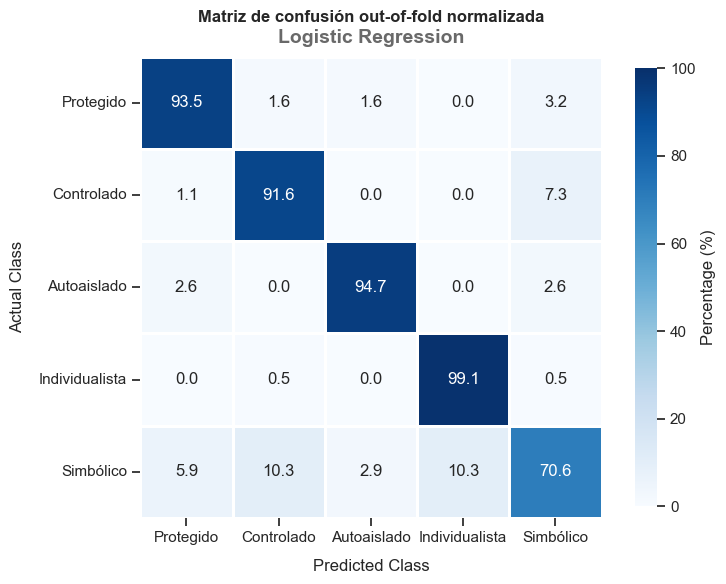

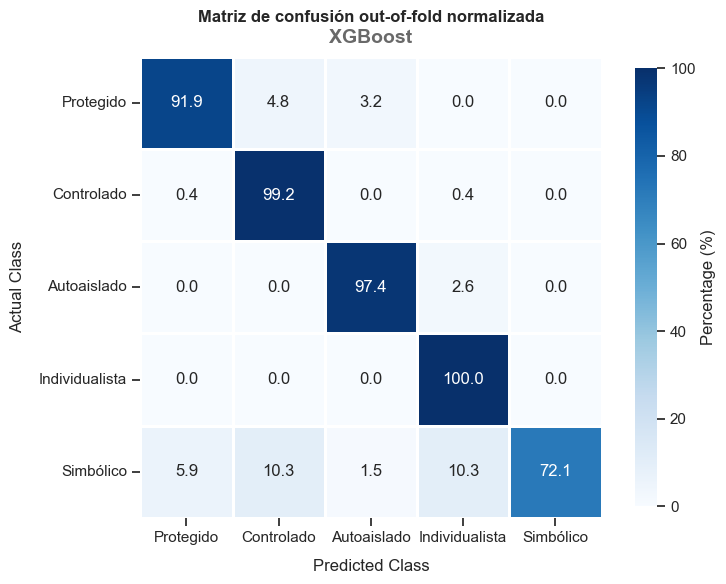

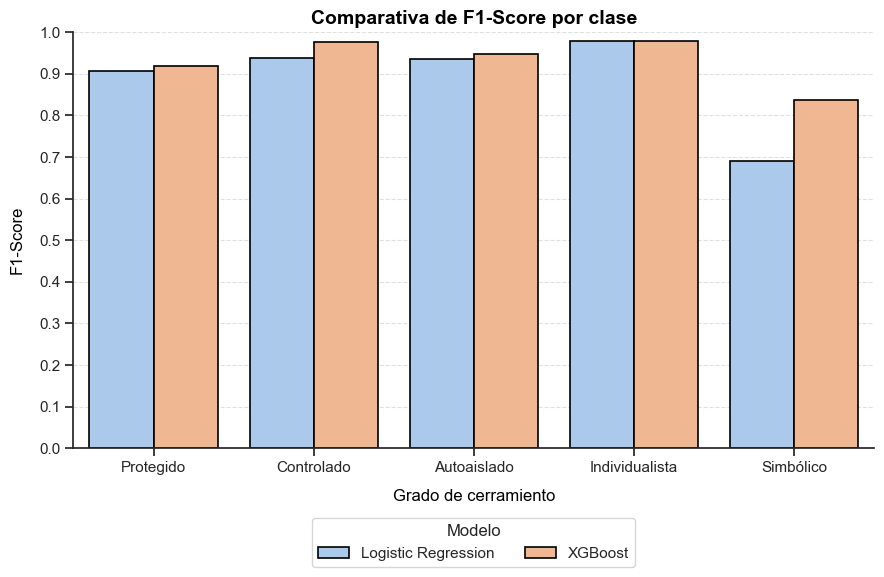

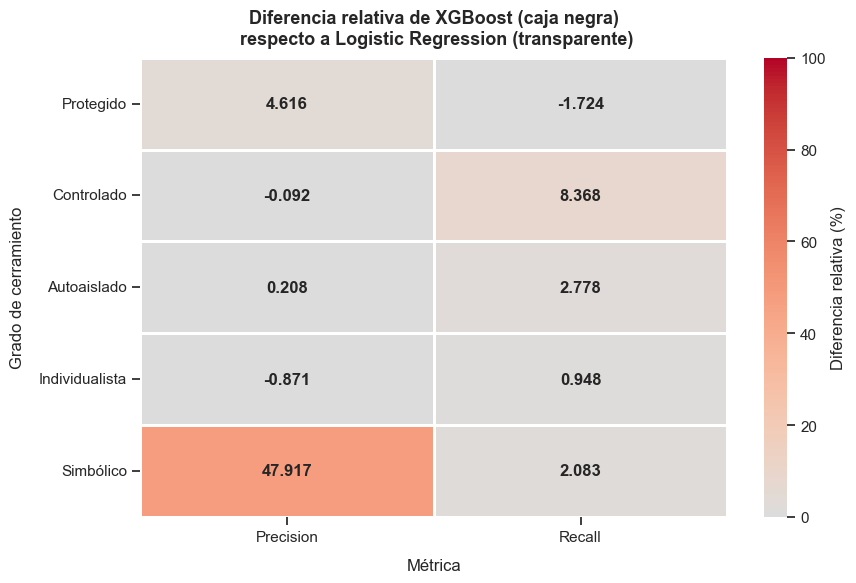

In [47]:
models_name = ["Logistic_Regression", "XGBoost"]
list_metrics_df = []
for model in models_name:
    # Read confusion matrix file
    confusion_matrix_df = pd.read_csv(results_folder / model / f"{model}_confusion_matrix.csv", index_col=0)
    
    # Read class metric file
    list_metrics_df.append(pd.read_csv(results_folder/ model / f"{model}_class_metrics.csv"))

    # Plot Confusion Matrix
    _ = plot_confusion_matrix(confusion_matrix_df, label_map=cfg.TARGET_LABEL_MAP, model_name=model)

# Concatenate class metrics files and plot visualizations
class_metrics_df = pd.concat(list_metrics_df, ignore_index=True)
_ = compare_class_metrics(class_metrics_df, models_name[0], models_name[1], label_map=cfg.TARGET_LABEL_MAP)

En el gráfico de barras se observa que las diferencias de rendimiento entre XGBoost y la regresión logística multinomial, en términos de F1-Score por clase, son considerablemente más reducidas que en la comparación anterior con el árbol de decisión. No obstante, la categoría más beneficiada por el uso de XGBoost vuelve a ser *Simbólico*, que se posiciona como el grado de cerramiento más difícil de clasificar para los modelos evaluados.

El Heat Map muestra que la principal mejora de XGBoost se concentra en un incremento relativo de la precisión, en la categoría *Simbólico*, del $47.91\%$, mientras que en términos de recall se produce un ligero incremento del $\approx2\%$. Estos resultados indican que la regresión logística multinomial consigue clasificar correctamente los complejos residenciales *Simbólicos* reales en proporciones similares a XGBoost. Sin embargo, se ve más afectado por los falsos positivos lo que penaliza su precisión en esta categoría.

Tal y como se observa en la matriz de confusión, XGBoost elimina completamente los errores de Tipo I en esta categoría, lo que mejora de forma significativa la capacidad del modelo para discriminar la clase *Simbólico* frente al resto.

En la regresión logística, la clase que más contribuye al error de Tipo I en el grado de cerramiento *Simbólico* es *Controlado*. En este sentido, XGBoost logra además un incremento relativo del $8.36%$ en el recall de la clase *Controlado*.

Para la clase *Protegido*, XGBoost mejora la precisión a costa de una ligera reducción del recall. No obstante, la matriz de confusión muestra que, con regresión logística, la clase *Protegido* se confunde con *Controlado*, *Autoaislado* y *Simbólico*. Con XGBoost, esta confusión se reduce a las clases *Controlado* y *Autoaislado*, eliminándose la confusión con *Simbólico*, que resulta especialmente relevante al tratarse del grado de cerramiento opuesto en términos de intensidad.

En el resto de categorías, las diferencias de rendimiento entre ambos modelos son reducidas. Este análisis sitúa a la regresión logística multinomial como una alternativa sólida cuando se busca equilibrar interpretabilidad y rendimiento, ya que mantiene un comportamiento muy competitivo frente a XGBoost en todas las clases.

No obstante, XGBoost permite refinar el rendimiento, especialmente en la discriminación de la categoría *Simbólico*. Este incremento en la precisión aporta una mayor certeza de que los complejos residenciales clasificados como *Simbólicos* pertenecen realmente a dicha categoría, a la vez que mejora la tasa de acierto en el resto de clases. Esta mejora no solo es relevante en términos de rendimiento, sino que también tiene un efecto directo sobre la interpretabilidad del modelo. Una alta precisión en la clase *Simbólico* garantiza que las interpretaciones asociadas a esta categoría reflejen de forma más fiel el comportamiento aprendido por el modelo, al basarse únicamente en observaciones correctamente clasificadas como tales.